Kelompok 5 


1.Febry Aulia Utami Ahmad


2.Muhammad Nadhif Ihdar


# Preprocessing Data Penjualan - Kelompok 5

Notebook ini berisi tahapan preprocessing data pada dataset `SCB_dataset_preprocessing_penjualan.csv`. Setiap tahapan disusun dengan format: **penjelasan singkat → kode → output → interpretasi hasil**, mulai dari eksplorasi data awal, penanganan missing value, standarisasi kategori, penanganan outlier, feature engineering, normalisasi/standarisasi, hingga validasi dan penyimpanan dataset akhir.

### Tahap 1: Import Library
Tahap ini mengimpor seluruh pustaka (library) Python yang dibutuhkan untuk keperluan analisis dan preprocessing data, seperti `numpy` dan `pandas` untuk manipulasi data, `matplotlib` dan `seaborn` untuk visualisasi, serta beberapa modul dari `scikit-learn` (`MinMaxScaler`, `StandardScaler`, `KNNImputer`, `PCA`) untuk kebutuhan transformasi data lebih lanjut.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

print("Library berhasil di-import.")


Library berhasil di-import.


**Interpretasi:** Seluruh library berhasil diimpor tanpa error, yang ditandai dengan pesan `Library berhasil di-import.`. Ini menandakan environment sudah siap digunakan untuk tahap-tahap analisis dan preprocessing selanjutnya.

### Tahap 2: Memuat Dataset
Dataset `SCB_dataset_preprocessing_penjualan.csv` dimuat ke dalam DataFrame `df_raw` menggunakan `pandas.read_csv()`. Perintah `head()` digunakan untuk menampilkan 5 baris pertama guna memastikan data telah terbaca dengan benar dan memberikan gambaran awal mengenai struktur kolom.

In [2]:
df_raw = pd.read_csv("SCB_dataset_preprocessing_penjualan.csv")

df_raw.head()

,Order_ID,Customer_ID,Jenis_Kelamin,Kota,Kategori_Produk,Metode_Pembayaran,Jumlah_Barang,Harga_Satuan,Diskon_Persen,Lama_Pengiriman_Hari,Rating_Pelanggan,Total_Belanja
0,SCB-ORD0001,SCB-CUST015,Perempuan,Takalar,Kesehatan,Kartu Kredit,2,696101.0,30,5.0,5.0,974541.0
1,SCB-ORD0002,SCB-CUST220,Laki-laki,Takalar,Elektronik,COD,1,4677390.0,5,2.0,4.1,4443520.0
2,SCB-ORD0003,SCB-CUST010,Laki-laki,Maros,Kesehatan,Kartu Kredit,2,154647.0,25,4.0,3.1,231970.0
3,SCB-ORD0004,SCB-CUST161,Laki-laki,Makassar,Kesehatan,Kartu Kredit,1,536223.0,0,6.0,3.9,536223.0
4,SCB-ORD0005,SCB-CUST057,Laki-laki,Takalar,Makanan,E-Wallet,1,16092.0,5,5.0,4.3,15287.0


**Interpretasi:** Dataset berhasil dimuat dan terdiri dari 12 kolom, mencakup data identitas transaksi (`Order_ID`, `Customer_ID`), data demografis (`Jenis_Kelamin`, `Kota`), serta data transaksi (`Kategori_Produk`, `Metode_Pembayaran`, `Jumlah_Barang`, `Harga_Satuan`, `Diskon_Persen`, `Lama_Pengiriman_Hari`, `Rating_Pelanggan`, `Total_Belanja`). Tampilan awal ini juga sudah memperlihatkan variasi kota dan kategori produk yang akan dibersihkan lebih lanjut.

### Tahap 3: Ukuran Dataset
Tahap ini menampilkan dimensi dataset, yaitu jumlah observasi (baris) dan jumlah atribut (kolom), untuk mengetahui skala data yang akan diproses.

In [3]:
print("Jumlah obseervasi :", df_raw.shape[0])
print("Jumlah atribut :", df_raw.shape[1])
print("Ukuran dataset :", df_raw.shape)

Jumlah obseervasi : 400
Jumlah atribut : 12
Ukuran dataset : (400, 12)


**Interpretasi:** Dataset berisi 400 observasi (baris) dan 12 atribut (kolom). Informasi ini menjadi acuan awal skala data sebelum dan sesudah preprocessing.

### Tahap 4: Informasi Struktur Data
Fungsi `df_raw.info()` digunakan untuk melihat tipe data setiap kolom serta jumlah nilai non-null (non-kosong) pada masing-masing kolom. Informasi ini penting untuk mendeteksi keberadaan missing value dan memastikan tipe data setiap atribut sudah sesuai.

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Order_ID              400 non-null    str    
 1   Customer_ID           400 non-null    str    
 2   Jenis_Kelamin         395 non-null    str    
 3   Kota                  394 non-null    str    
 4   Kategori_Produk       400 non-null    str    
 5   Metode_Pembayaran     395 non-null    str    
 6   Jumlah_Barang         400 non-null    int64  
 7   Harga_Satuan          394 non-null    float64
 8   Diskon_Persen         400 non-null    int64  
 9   Lama_Pengiriman_Hari  396 non-null    float64
 10  Rating_Pelanggan      395 non-null    float64
 11  Total_Belanja         400 non-null    float64
dtypes: float64(4), int64(2), str(6)
memory usage: 37.6 KB


**Interpretasi:** Terlihat bahwa beberapa kolom memiliki jumlah non-null di bawah 400 (misalnya `Jenis_Kelamin`: 395, `Kota`: 394, `Metode_Pembayaran`: 395, `Harga_Satuan`: 394, `Lama_Pengiriman_Hari`: 396, `Rating_Pelanggan`: 395), yang mengindikasikan adanya missing value pada kolom-kolom tersebut. Tipe data pada masing-masing kolom juga sudah sesuai dengan jenis informasinya (numerik untuk nilai transaksi, string untuk identitas dan kategori).

### Tahap 5: Statistik Deskriptif
Fungsi `df_raw.describe()` digunakan untuk menghasilkan ringkasan statistik (mean, standar deviasi, minimum, kuartil, dan maksimum) dari kolom-kolom numerik. Ringkasan ini membantu mendeteksi indikasi awal adanya outlier atau nilai yang tidak wajar (misalnya nilai negatif pada `Diskon_Persen` atau `Rating_Pelanggan`).

In [5]:
df_raw.describe()

,Jumlah_Barang,Harga_Satuan,Diskon_Persen,Lama_Pengiriman_Hari,Rating_Pelanggan,Total_Belanja
count,400.000000,3.940000e+02,400.000000,396.000000,395.000000,4.000000e+02
mean,2.635000,1.267100e+06,15.250000,4.762626,4.137468,2.044498e+06
std,4.558368,3.656738e+06,10.844654,4.437381,0.649884,3.536089e+06
min,1.000000,1.005500e+04,-15.000000,1.000000,-1.000000,7.845000e+03
25%,1.000000,2.403012e+05,5.000000,3.000000,3.700000,3.558798e+05
50%,2.000000,5.235195e+05,15.000000,5.000000,4.200000,8.630290e+05
75%,3.000000,1.146158e+06,25.000000,6.000000,4.600000,1.943110e+06
max,75.000000,5.500000e+07,105.000000,70.000000,6.500000,2.497580e+07


**Interpretasi:** Ditemukan beberapa nilai yang tidak wajar secara logis, seperti `Diskon_Persen` bernilai minimum -15 dan maksimum 105 (seharusnya berada pada rentang 0-100), serta `Rating_Pelanggan` bernilai minimum -1 dan maksimum 6.5 (seharusnya berada pada rentang 0-5). Selain itu, nilai maksimum pada `Harga_Satuan` dan `Total_Belanja` jauh lebih tinggi dibanding kuartil ketiga (Q3), yang mengindikasikan adanya outlier. Temuan ini menjadi dasar bagi tahap penanganan data tidak valid dan outlier selanjutnya.

### Tahap 6: Deteksi Missing Value (Seluruh Kolom)
Tahap ini menghitung jumlah nilai kosong (missing value) pada setiap kolom menggunakan `isnull().sum()` untuk mengetahui kolom mana saja yang memiliki data yang hilang.

In [6]:
jumlah_missing = df_raw.isnull().sum()

print(jumlah_missing)

Order_ID                0
Customer_ID             0
Jenis_Kelamin           5
Kota                    6
Kategori_Produk         0
Metode_Pembayaran       5
Jumlah_Barang           0
Harga_Satuan            6
Diskon_Persen           0
Lama_Pengiriman_Hari    4
Rating_Pelanggan        5
Total_Belanja           0
dtype: int64


**Interpretasi:** Kolom `Jenis_Kelamin`, `Kota`, dan `Metode_Pembayaran` masing-masing memiliki beberapa nilai kosong, begitu pula `Harga_Satuan`, `Lama_Pengiriman_Hari`, dan `Rating_Pelanggan`. Kolom identitas (`Order_ID`, `Customer_ID`), `Kategori_Produk`, `Jumlah_Barang`, `Diskon_Persen`, dan `Total_Belanja` tidak memiliki missing value.

### Tahap 7: Filter Kolom dengan Missing Value
Hasil perhitungan missing value pada tahap sebelumnya difilter agar hanya menampilkan kolom yang benar-benar memiliki nilai kosong, sehingga lebih mudah difokuskan penanganannya.

In [7]:
jumlah_missing = df_raw.isnull().sum()

print(jumlah_missing[jumlah_missing>0])

Jenis_Kelamin           5
Kota                    6
Metode_Pembayaran       5
Harga_Satuan            6
Lama_Pengiriman_Hari    4
Rating_Pelanggan        5
dtype: int64


**Interpretasi:** Dengan memfilter hanya kolom yang bernilai lebih dari 0, terlihat jelas bahwa terdapat 6 kolom yang perlu ditangani missing value-nya, yaitu `Jenis_Kelamin`, `Kota`, `Metode_Pembayaran`, `Harga_Satuan`, `Lama_Pengiriman_Hari`, dan `Rating_Pelanggan`.

### Tahap 8: Ringkasan Persentase Missing Value
Tahap ini menghitung persentase missing value terhadap total data pada setiap kolom yang memiliki nilai kosong, kemudian menyajikannya dalam bentuk tabel ringkasan (`Jumlah_Missing` dan `Persentase_Missing`) agar tingkat keparahan missing value lebih mudah dipahami.

In [8]:
persentase_missing = (
    df_raw.isnull().sum() / len(df_raw) * 100
).round(2)

ringkasan_missing = pd.DataFrame({
    "Jumlah_Missing": df_raw.isnull().sum(),
    "Persentase_Missing": persentase_missing
})

ringkasan_missing = ringkasan_missing[
    ringkasan_missing["Jumlah_Missing"] > 0
]
ringkasan_missing

,Jumlah_Missing,Persentase_Missing
Jenis_Kelamin,5,1.25
Kota,6,1.50
Metode_Pembayaran,5,1.25
Harga_Satuan,6,1.50
Lama_Pengiriman_Hari,4,1.00
Rating_Pelanggan,5,1.25


**Interpretasi:** Persentase missing value pada setiap kolom relatif kecil, yaitu berkisar antara 1.00% hingga 1.50% dari total 400 data. Karena persentasenya kecil, penanganan dengan imputasi (median untuk numerik, modus untuk kategorikal) merupakan strategi yang tepat dibandingkan menghapus baris data tersebut.

### Tahap 9: Penanganan Missing Value
Dataset disalin ke `df_cleaned`, kemudian data duplikat dihapus. Missing value pada kolom kategorikal (`Jenis_Kelamin`, `Kota`, `Metode_Pembayaran`) diisi menggunakan nilai modus (nilai yang paling sering muncul), sedangkan missing value pada kolom numerik (`Harga_Satuan`, `Lama_Pengiriman_Hari`, `Rating_Pelanggan`) diisi menggunakan nilai median agar tidak sensitif terhadap outlier.

In [9]:
df_cleaned = df_raw.copy()

df_cleaned = df_cleaned.drop_duplicates()

kolom_kategorikal = ["Jenis_Kelamin", "Kota", "Metode_Pembayaran"]
for col in kolom_kategorikal:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

kolom_numerik = ["Harga_Satuan", "Lama_Pengiriman_Hari", "Rating_Pelanggan"]
for col in kolom_numerik:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

print("Total missing value setelah ditangani:", df_cleaned.isnull().sum().sum())
print("Jumlah duplikat setelah dibersihkan:", df_cleaned.duplicated().sum())

Total missing value setelah ditangani: 0
Jumlah duplikat setelah dibersihkan: 0


**Interpretasi:** Setelah proses imputasi, total missing value pada `df_cleaned` menjadi 0 dan jumlah duplikat juga tercatat 0, yang menunjukkan tahap penanganan missing value telah berhasil dilakukan dengan baik.

### Tahap 10: Verifikasi Data Duplikat
Tahap ini memeriksa kembali jumlah baris duplikat pada `df_cleaned` sebelum dan sesudah proses `drop_duplicates()` untuk memastikan tidak ada lagi data yang terduplikasi.

In [10]:
print("Jumlah data duplikat sebelum dihapus:", df_cleaned.duplicated().sum())

df_cleaned = df_cleaned.drop_duplicates().copy()

print("Jumlah data duplikat setelah dihapus:", df_cleaned.duplicated().sum())

Jumlah data duplikat sebelum dihapus: 0
Jumlah data duplikat setelah dihapus: 0


**Interpretasi:** Baik sebelum maupun sesudah proses `drop_duplicates()` pada `df_cleaned`, jumlah data duplikat tercatat 0. Hal ini karena duplikat sebenarnya sudah dihapus pada tahap sebelumnya, sehingga langkah ini berfungsi sebagai verifikasi ulang.

### Tahap 11: Menampilkan Data Duplikat pada Data Mentah
Tahap ini menampilkan baris-baris yang teridentifikasi sebagai duplikat pada `df_raw` (menggunakan `keep=False` agar seluruh baris yang beririsan ikut ditampilkan) untuk memverifikasi secara visual data mana saja yang identik.

In [11]:
data_duplikat = df_raw[
    df_raw.duplicated(keep=False)
]

data_duplikat

,Order_ID,Customer_ID,Jenis_Kelamin,Kota,Kategori_Produk,Metode_Pembayaran,Jumlah_Barang,Harga_Satuan,Diskon_Persen,Lama_Pengiriman_Hari,Rating_Pelanggan,Total_Belanja
30,SCB-ORD0031,SCB-CUST131,Perempuan,Gowa,Fashion,E-Wallet,1,180716.0,20,2.0,4.4,144573.0
95,SCB-ORD0096,SCB-CUST130,Laki-laki,Parepare,Makanan,COD,2,214351.0,20,6.0,3.5,342962.0
180,SCB-ORD0181,SCB-CUST094,Perempuan,Makassar,Rumah Tangga,Kartu Kredit,1,1616786.0,5,2.0,3.9,1535947.0
270,SCB-ORD0271,SCB-CUST042,Perempuan,Makassar,Makanan,Kartu Kredit,3,305352.0,20,3.0,4.0,732845.0
385,SCB-ORD0386,SCB-CUST022,Laki-laki,Gowa,Elektronik,Transfer Bank,1,2956581.0,25,5.0,4.4,2217436.0
395,SCB-ORD0031,SCB-CUST131,Perempuan,Gowa,Fashion,E-Wallet,1,180716.0,20,2.0,4.4,144573.0
396,SCB-ORD0096,SCB-CUST130,Laki-laki,Parepare,Makanan,COD,2,214351.0,20,6.0,3.5,342962.0
397,SCB-ORD0181,SCB-CUST094,Perempuan,Makassar,Rumah Tangga,Kartu Kredit,1,1616786.0,5,2.0,3.9,1535947.0
398,SCB-ORD0271,SCB-CUST042,Perempuan,Makassar,Makanan,Kartu Kredit,3,305352.0,20,3.0,4.0,732845.0
399,SCB-ORD0386,SCB-CUST022,Laki-laki,Gowa,Elektronik,Transfer Bank,1,2956581.0,25,5.0,4.4,2217436.0


**Interpretasi:** Ditemukan 5 baris data pada `df_raw` yang memiliki pasangan duplikat persis (total 10 baris teridentifikasi karena `keep=False`), misalnya `SCB-ORD0031` dan `SCB-ORD0386`. Temuan ini mengonfirmasi perlunya proses `drop_duplicates()` yang telah dilakukan pada `df_cleaned`.

### Tahap 12: Standarisasi Nilai Kategori Tidak Konsisten
Tahap ini menyeragamkan penulisan nilai-nilai kategorikal yang tidak konsisten (misalnya variasi penulisan `LK`/`lk`/`laki-laki`, `mks`/`mksr`, `elektronik`/`Elektronik `, `Ewallet`/`ewallet`) pada kolom `Jenis_Kelamin`, `Kota`, `Kategori_Produk`, dan `Metode_Pembayaran` menggunakan `dictionary mapping` dan `replace()`, sehingga setiap kategori memiliki satu bentuk penulisan yang baku.

In [12]:
mapping_kelamin = {
    "lk": "Laki-laki",
    "LK": "Laki-laki",
    "laki-laki": "Laki-laki",
    "Laki Laki": "Laki-laki",
    "pr": "Perempuan",
    "PR": "Perempuan",
    "perempuan": "Perempuan",
}
df_raw["Jenis_Kelamin"] = df_raw["Jenis_Kelamin"].replace(mapping_kelamin)
print("--- Nilai Unik Jenis Kelamin (df_raw) ---")
print(df_raw["Jenis_Kelamin"].value_counts(), "\n")

mapping_kota = {
    "mks": "Makassar",
    "makassar": "Makassar",
    "mksr": "Makassar",
    "gowa ": "Gowa",
    "gowa": "Gowa",
}
df_raw["Kota"] = df_raw["Kota"].replace(mapping_kota)
print("--- Nilai Unik Kota (df_raw) ---")
print(df_raw["Kota"].value_counts(), "\n")

mapping_kategori = {
    "elektronik": "Elektronik",
    "Elektronik ": "Elektronik",
    "fashion": "Fashion",
    "pakaian": "Fashion",
    "peralatan rumah tangga": "Peralatan Rumah Tangga",
}
df_raw["Kategori_Produk"] = df_raw["Kategori_Produk"].replace(mapping_kategori)
print("--- Nilai Unik Kategori Produk (df_raw) ---")
print(df_raw["Kategori_Produk"].value_counts(), "\n")

mapping_pembayaran = {
    "transfer bank": "Transfer Bank",
    "Transfer": "Transfer Bank",
    "cod": "COD",
    "Cash on Delivery": "COD",
    "E-Wallet": "E-Wallet",
    "ewallet": "E-Wallet",
}
df_raw["Metode_Pembayaran"] = df_raw["Metode_Pembayaran"].replace(
    mapping_pembayaran
)
print("--- Nilai Unik Metode Pembayaran (df_raw) ---")
print(df_raw["Metode_Pembayaran"].value_counts())

--- Nilai Unik Jenis Kelamin (df_raw) ---
Jenis_Kelamin
Laki-laki    205
Perempuan    189
LAKI-LAKI      1
Name: count, dtype: int64 

--- Nilai Unik Kota (df_raw) ---
Kota
Parepare     73
Makassar     68
Takalar      67
Maros        65
Gowa         60
Bone         58
MAROS         1
takalar       1
Pare Pare     1
Name: count, dtype: int64 

--- Nilai Unik Kategori Produk (df_raw) ---
Kategori_Produk
Rumah Tangga    85
Fashion         84
Kesehatan       79
Makanan         78
Elektronik      71
Makanan          1
kesehatan        1
Rumah-tangga     1
Name: count, dtype: int64 

--- Nilai Unik Metode Pembayaran (df_raw) ---
Metode_Pembayaran
Kartu Kredit     106
Transfer Bank    101
E-Wallet          93
COD               92
Ewallet            1
bank transfer      1
KartuKredit        1
Name: count, dtype: int64


**Interpretasi:** Setelah dilakukan mapping, sebagian besar nilai kategori sudah seragam (misalnya `Laki-laki` sebanyak 205 dan `Perempuan` sebanyak 189), namun `df_raw` (bukan `df_cleaned`) masih menyisakan sedikit variasi penulisan yang belum tertangkap oleh mapping, seperti `LAKI-LAKI`, `MAROS`, `takalar`, `Pare Pare`, `Makanan ` (dengan spasi), `kesehatan`, `Rumah-tangga`, `Ewallet`, `bank transfer`, dan `KartuKredit`. Hal ini menunjukkan pentingnya melengkapi dictionary mapping agar seluruh variasi penulisan benar-benar konsisten.

### Tahap 13: Deteksi dan Penanganan Nilai Tidak Valid
Tahap ini mengidentifikasi baris dengan nilai yang secara logis tidak valid, misalnya `Diskon_Persen` di luar rentang 0-100, `Rating_Pelanggan` di luar rentang 0-5, atau `Jumlah_Barang` bernilai nol/negatif. Nilai-nilai tersebut kemudian dibatasi (di-*clip*) ke rentang yang wajar.

In [13]:
invalid_data = df_raw[
    (df_raw["Diskon_Persen"] < 0)
    | (df_raw["Diskon_Persen"] > 100)
    | (df_raw["Rating_Pelanggan"] < 0)
    | (df_raw["Rating_Pelanggan"] > 5)
    | (df_raw["Jumlah_Barang"] <= 0)
]
display(
    invalid_data[["Order_ID", "Jumlah_Barang", "Diskon_Persen", "Rating_Pelanggan"]]
)

df_raw["Jumlah_Barang"] = df_raw["Jumlah_Barang"].clip(lower=1)
df_raw["Diskon_Persen"] = df_raw["Diskon_Persen"].clip(lower=0, upper=100)
df_raw["Rating_Pelanggan"] = df_raw["Rating_Pelanggan"].clip(lower=1, upper=5)

print("\n=== RINGKASAN MIN & MAX SETELAH PENANGANAN ===")
display(
    df_raw[["Jumlah_Barang", "Diskon_Persen", "Rating_Pelanggan"]].agg(["min", "max"])
)

,Order_ID,Jumlah_Barang,Diskon_Persen,Rating_Pelanggan
153,SCB-ORD0154,4,105,2.8
187,SCB-ORD0188,3,30,6.5
301,SCB-ORD0302,3,-15,4.2
365,SCB-ORD0366,4,25,-1.0



=== RINGKASAN MIN & MAX SETELAH PENANGANAN ===


,Jumlah_Barang,Diskon_Persen,Rating_Pelanggan
min,1,0,1.0
max,75,100,5.0


**Interpretasi:** Ditemukan 4 baris dengan nilai tidak valid, yaitu `Diskon_Persen` sebesar 105% dan -15%, serta `Rating_Pelanggan` sebesar 6.5 dan -1.0. Setelah dilakukan `clip()`, seluruh nilai `Jumlah_Barang`, `Diskon_Persen`, dan `Rating_Pelanggan` kini berada pada rentang yang logis (masing-masing 1-75, 0-100, dan 1-5), menandakan proses koreksi nilai tidak valid berhasil dilakukan.

### Tahap 14: Deteksi Outlier dengan Metode IQR
Tahap ini mendeteksi outlier pada kolom `Harga_Satuan`, `Total_Belanja`, dan `Lama_Pengiriman_Hari` menggunakan metode *Interquartile Range* (IQR), yaitu nilai di luar rentang `Q1 - 1.5*IQR` hingga `Q3 + 1.5*IQR` dianggap outlier. Hasilnya divisualisasikan menggunakan boxplot untuk masing-masing atribut.

--- DETEKSI OUTLIER MENGGUNAKAN METODE IQR ---
Atribut Harga_Satuan:
  - Q1: 240301.25 | Q3: 1146157.50 | IQR: 905856.25
  - Batas Bawah: -1118483.12 | Batas Atas: 2504941.88
  - Jumlah Outlier: 45 baris

Atribut Total_Belanja:
  - Q1: 355879.75 | Q3: 1943110.50 | IQR: 1587230.75
  - Batas Bawah: -2024966.38 | Batas Atas: 4323956.62
  - Jumlah Outlier: 46 baris

Atribut Lama_Pengiriman_Hari:
  - Q1: 3.00 | Q3: 6.00 | IQR: 3.00
  - Batas Bawah: -1.50 | Batas Atas: 10.50
  - Jumlah Outlier: 2 baris



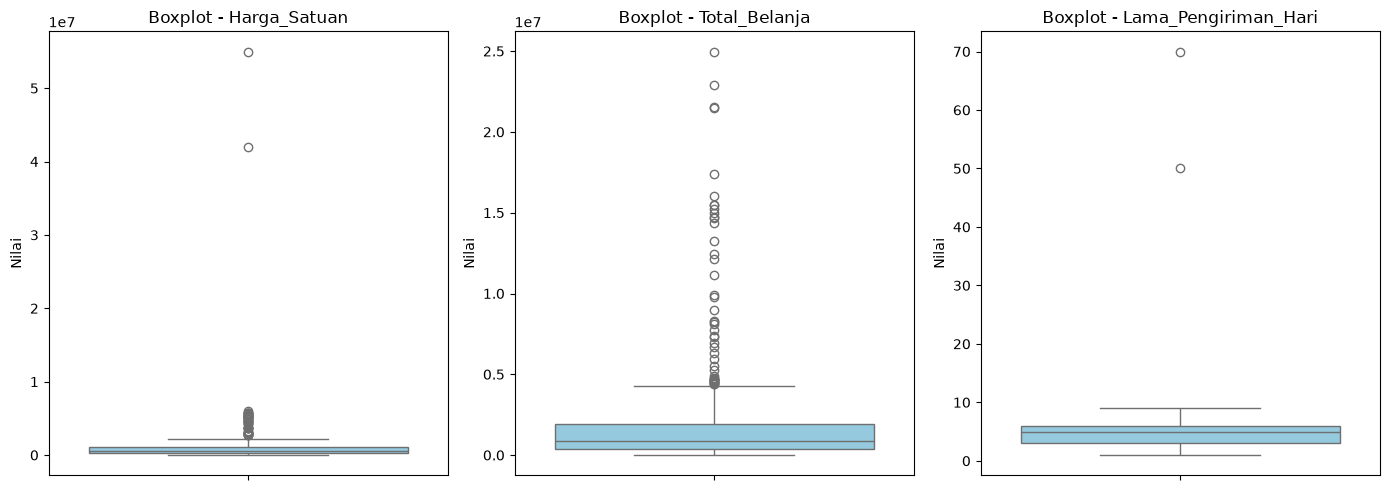

In [14]:
fitur_numerik = ["Harga_Satuan", "Total_Belanja", "Lama_Pengiriman_Hari"]

print("--- DETEKSI OUTLIER MENGGUNAKAN METODE IQR ---")
for kolom in fitur_numerik:
    Q1 = df_raw[kolom].quantile(0.25)
    Q3 = df_raw[kolom].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_raw[(df_raw[kolom] < lower_bound) | (df_raw[kolom] > upper_bound)]
    
    print(f"Atribut {kolom}:")
    print(f"  - Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"  - Batas Bawah: {lower_bound:.2f} | Batas Atas: {upper_bound:.2f}")
    print(f"  - Jumlah Outlier: {len(outliers)} baris\n")

plt.figure(figsize=(14, 5))
for i, kolom in enumerate(fitur_numerik, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_raw[kolom], color='skyblue')
    plt.title(f"Boxplot - {kolom}")
    plt.ylabel("Nilai")

plt.tight_layout()
plt.show()

**Interpretasi:** Metode IQR mendeteksi 45 outlier pada `Harga_Satuan`, 46 outlier pada `Total_Belanja`, dan 2 outlier pada `Lama_Pengiriman_Hari`. Visualisasi boxplot memperkuat temuan ini dengan memperlihatkan banyak titik data yang berada jauh di luar kotak (box) pada atribut `Harga_Satuan` dan `Total_Belanja`, mengindikasikan distribusi data yang menceng (skewed) ke kanan akibat beberapa transaksi bernilai sangat besar.

### Tahap 15: Perbandingan Metode IQR dan Z-Score
Tahap ini membandingkan jumlah outlier yang terdeteksi pada atribut `Harga_Satuan` antara metode IQR dan metode Z-Score (ambang batas |Z| > 3), sekaligus menampilkan detail baris data yang teridentifikasi sebagai outlier oleh masing-masing metode.

In [15]:
import scipy.stats as stats
kolom_target = "Harga_Satuan"

Q1 = df_raw[kolom_target].quantile(0.25)
Q3 = df_raw[kolom_target].quantile(0.75)
IQR = Q3 - Q1
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

outlier_iqr_idx = df_raw[(df_raw[kolom_target] < lower_bound_iqr) | (df_raw[kolom_target] > upper_bound_iqr)].index

z_scores = np.abs(stats.zscore(df_raw[kolom_target].dropna()))
z_scores_series = pd.Series(z_scores, index=df_raw[kolom_target].dropna().index)
outlier_z_idx = z_scores_series[z_scores_series > 3].index

print(f"--- PERBANDINGAN OUTLIER PADA ATRIBUT '{kolom_target}' ---")
print(f"Jumlah outlier metode IQR : {len(outlier_iqr_idx)} baris (Indeks: {list(outlier_iqr_idx)})")
print(f"Jumlah outlier metode Z-Score: {len(outlier_z_idx)} baris (Indeks: {list(outlier_z_idx)})")


print("\nDetail Data Outlier (IQR):")
display(df_raw.loc[outlier_iqr_idx, ['Order_ID', kolom_target]])

print("\nDetail Data Outlier (Z-Score):")
display(df_raw.loc[outlier_z_idx, ['Order_ID', kolom_target]])

--- PERBANDINGAN OUTLIER PADA ATRIBUT 'Harga_Satuan' ---
Jumlah outlier metode IQR : 45 baris (Indeks: [1, 11, 21, 25, 29, 33, 35, 47, 54, 55, 61, 73, 74, 91, 98, 121, 167, 168, 173, 176, 201, 216, 226, 231, 283, 287, 295, 298, 302, 304, 307, 319, 322, 329, 338, 345, 353, 354, 364, 365, 370, 373, 385, 394, 399])
Jumlah outlier metode Z-Score: 2 baris (Indeks: [98, 287])

Detail Data Outlier (IQR):


,Order_ID,Harga_Satuan
1,SCB-ORD0002,4677390.0
11,SCB-ORD0012,5718388.0
21,SCB-ORD0022,2774674.0
25,SCB-ORD0026,4653916.0
29,SCB-ORD0030,2898262.0
33,SCB-ORD0034,3033110.0
35,SCB-ORD0036,5293482.0
47,SCB-ORD0048,5675796.0
54,SCB-ORD0055,5372492.0
55,SCB-ORD0056,3259594.0



Detail Data Outlier (Z-Score):


,Order_ID,Harga_Satuan
98,SCB-ORD0099,42000000.0
287,SCB-ORD0288,55000000.0


**Interpretasi:** Metode IQR jauh lebih sensitif dibandingkan Z-Score dalam mendeteksi outlier pada atribut `Harga_Satuan` (45 baris vs 2 baris). Z-Score hanya menandai dua nilai yang sangat ekstrem (Rp42.000.000 dan Rp55.000.000) sebagai outlier, sementara IQR juga menandai nilai-nilai yang cukup tinggi namun masih relatif wajar (kisaran Rp2,7 juta - Rp6 juta). Hal ini menunjukkan pentingnya memilih metode deteksi outlier sesuai karakteristik dan sebaran data.

### Tahap 16: Penanganan Outlier dengan Capping
Outlier pada kolom `Harga_Satuan` ditangani dengan teknik *capping*, yaitu nilai yang berada di bawah batas bawah atau di atas batas atas IQR dibatasi (di-*clip*) agar berada tepat pada batas tersebut, sehingga nilai ekstrem tidak dihapus namun disesuaikan.

In [16]:
kolom_target = "Harga_Satuan"

Q1 = df_raw[kolom_target].quantile(0.25)
Q3 = df_raw[kolom_target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df_raw.copy()

df_cleaned[kolom_target] = df_cleaned[kolom_target].clip(lower=lower_bound, upper=upper_bound)

print(f"--- STRATEGI PENANGANAN OUTLIER PADA '{kolom_target}' ---")
print(f"Batas Bawah Capping: {lower_bound:.2f}")
print(f"Batas Atas Capping : {upper_bound:.2f}")
print("\nRingkasan statistik setelah dilakukan capping:")
display(df_cleaned[kolom_target].describe())

--- STRATEGI PENANGANAN OUTLIER PADA 'Harga_Satuan' ---
Batas Bawah Capping: -1118483.12
Batas Atas Capping : 2504941.88

Ringkasan statistik setelah dilakukan capping:


count    3.940000e+02
mean     8.270678e+05
std      7.720000e+05
min      1.005500e+04
25%      2.403012e+05
50%      5.235195e+05
75%      1.146158e+06
max      2.504942e+06
Name: Harga_Satuan, dtype: float64

**Interpretasi:** Setelah dilakukan *capping*, nilai maksimum `Harga_Satuan` yang semula mencapai puluhan juta kini terbatas pada Rp2.504.941,88 (batas atas IQR), sehingga rata-rata (mean) turun signifikan dari sekitar 1,27 juta menjadi sekitar 827 ribu. Hal ini menunjukkan bahwa nilai ekstrem sebelumnya sangat memengaruhi statistik ringkasan, dan proses capping berhasil membuat distribusi data lebih stabil tanpa kehilangan baris data.

### Tahap 17: Pemeriksaan Konsistensi Perhitungan Total Belanja
Tahap ini menghitung ulang `Total_Belanja` berdasarkan rumus `Harga_Satuan x Jumlah_Barang x (1 - Diskon_Persen/100)`, kemudian membandingkannya dengan nilai `Total_Belanja` asli untuk mengecek konsistensi data. Baris dengan selisih yang melebihi toleransi dianggap tidak konsisten.

In [17]:
df_cleaned["Total_Belanja_Hitung"] = (
    df_cleaned["Harga_Satuan"]
    * df_cleaned["Jumlah_Barang"]
    * (1 - df_cleaned["Diskon_Persen"] / 100)
)

selisih = np.abs(df_cleaned["Total_Belanja"] - df_cleaned["Total_Belanja_Hitung"])
toleransi = 1e-2
transaksi_tidak_konsisten = df_cleaned[selisih > toleransi]

print(f"Jumlah transaksi tidak konsisten: {len(transaksi_tidak_konsisten)}")
display(
    transaksi_tidak_konsisten[
        [
            "Order_ID",
            "Harga_Satuan",
            "Jumlah_Barang",
            "Diskon_Persen",
            "Total_Belanja",
            "Total_Belanja_Hitung",
        ]
    ]
)

Jumlah transaksi tidak konsisten: 300


,Order_ID,Harga_Satuan,Jumlah_Barang,Diskon_Persen,Total_Belanja,Total_Belanja_Hitung
0,SCB-ORD0001,696101.000,2,30,974541.0,9.745414e+05
1,SCB-ORD0002,2504941.875,1,5,4443520.0,2.379695e+06
2,SCB-ORD0003,154647.000,2,25,231970.0,2.319705e+05
4,SCB-ORD0005,16092.000,1,5,15287.0,1.528740e+04
6,SCB-ORD0007,438097.000,3,15,1117147.0,1.117147e+06
...,...,...,...,...,...,...
395,SCB-ORD0031,180716.000,1,20,144573.0,1.445728e+05
396,SCB-ORD0096,214351.000,2,20,342962.0,3.429616e+05
397,SCB-ORD0181,1616786.000,1,5,1535947.0,1.535947e+06
398,SCB-ORD0271,305352.000,3,20,732845.0,7.328448e+05


**Interpretasi:** Ditemukan 300 dari 400 transaksi yang nilai `Total_Belanja`-nya tidak sama persis dengan hasil perhitungan ulang (`Total_Belanja_Hitung`). Selisih ini kemungkinan besar disebabkan oleh proses *capping* pada `Harga_Satuan` di tahap sebelumnya, sehingga nilai `Harga_Satuan` yang digunakan untuk menghitung ulang berbeda dari nilai `Harga_Satuan` asli saat `Total_Belanja` pertama kali dicatat. Temuan ini penting untuk didokumentasikan agar tidak disalahartikan sebagai kesalahan input data.

### Tahap 18: Kategorisasi Data (Feature Engineering)
Tahap ini membuat dua atribut baru berbasis aturan (rule-based): `Kategori_Nilai_Transaksi` (Rendah/Sedang/Tinggi berdasarkan `Total_Belanja`) dan `Kategori_Lama_Pengiriman` (Cepat/Normal/Lambat berdasarkan `Lama_Pengiriman_Hari`).

In [18]:
def kategori_transaksi(total):
    if total < 500000:
        return "Rendah"
    elif total <= 2000000:
        return "Sedang"
    else:
        return "Tinggi"

df_cleaned["Kategori_Nilai_Transaksi"] = df_cleaned["Total_Belanja"].apply(kategori_transaksi)

def kategori_pengiriman(hari):
    if hari <= 3:
        return "Cepat"
    elif hari <= 5:
        return "Normal"
    else:
        return "Lambat"

df_cleaned["Kategori_Lama_Pengiriman"] = df_cleaned["Lama_Pengiriman_Hari"].apply(kategori_pengiriman)

display(df_cleaned[["Order_ID", "Total_Belanja", "Kategori_Nilai_Transaksi", "Lama_Pengiriman_Hari", "Kategori_Lama_Pengiriman"]].head())

,Order_ID,Total_Belanja,Kategori_Nilai_Transaksi,Lama_Pengiriman_Hari,Kategori_Lama_Pengiriman
0,SCB-ORD0001,974541.0,Sedang,5.0,Normal
1,SCB-ORD0002,4443520.0,Tinggi,2.0,Cepat
2,SCB-ORD0003,231970.0,Rendah,4.0,Normal
3,SCB-ORD0004,536223.0,Sedang,6.0,Lambat
4,SCB-ORD0005,15287.0,Rendah,5.0,Normal


**Interpretasi:** Kategorisasi berhasil diterapkan, misalnya transaksi `SCB-ORD0002` dengan `Total_Belanja` sebesar 4.443.520 dikategorikan `Tinggi` dan `Lama_Pengiriman_Hari` selama 2 hari dikategorikan `Cepat`. Fitur kategorikal baru ini akan mempermudah analisis atau visualisasi lebih lanjut dibandingkan menggunakan data numerik mentah.

### Tahap 19: Normalisasi dan Standarisasi Data
Fitur numerik (`Harga_Satuan`, `Jumlah_Barang`, `Lama_Pengiriman_Hari`, `Total_Belanja`) ditransformasi menggunakan dua teknik: **Min-Max Scaling** (menyekalakan nilai ke rentang 0-1) dan **Z-Score Standardization** (menyekalakan nilai agar memiliki rata-rata 0 dan standar deviasi 1), agar fitur-fitur dengan skala berbeda dapat dibandingkan atau digunakan pada model machine learning.

In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

fitur_skala = ["Harga_Satuan", "Jumlah_Barang", "Lama_Pengiriman_Hari", "Total_Belanja"]

print("--- DATA SEBELUM TRANSFORMASI ---")
display(df_cleaned[fitur_skala].head())

minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_cleaned[fitur_skala]), 
    columns=[f"{col}_MinMax" for col in fitur_skala], 
    index=df_cleaned.index
)

zscore_scaler = StandardScaler()
df_zscore = pd.DataFrame(
    zscore_scaler.fit_transform(df_cleaned[fitur_skala]), 
    columns=[f"{col}_ZScore" for col in fitur_skala], 
    index=df_cleaned.index
)

df_cleaned = pd.concat([df_cleaned, df_minmax, df_zscore], axis=1)

kolom_tampil = []
for col in fitur_skala:
    kolom_tampil.extend([col, f"{col}_MinMax", f"{col}_ZScore"])

print("\n--- DATA SETELAH TRANSFORMASI ---")
display(df_cleaned[kolom_tampil].head())

--- DATA SEBELUM TRANSFORMASI ---


,Harga_Satuan,Jumlah_Barang,Lama_Pengiriman_Hari,Total_Belanja
0,696101.000,2,5.0,974541.0
1,2504941.875,1,2.0,4443520.0
2,154647.000,2,4.0,231970.0
3,536223.000,1,6.0,536223.0
4,16092.000,1,5.0,15287.0



--- DATA SETELAH TRANSFORMASI ---


,Harga_Satuan,Harga_Satuan_MinMax,Harga_Satuan_ZScore,Jumlah_Barang,Jumlah_Barang_MinMax,Jumlah_Barang_ZScore,Lama_Pengiriman_Hari,Lama_Pengiriman_Hari_MinMax,Lama_Pengiriman_Hari_ZScore,Total_Belanja,Total_Belanja_MinMax,Total_Belanja_ZScore
0,696101.000,0.274981,-0.169862,2,0.013514,-0.139479,5.0,0.057971,0.053562,974541.0,0.038717,-0.302961
1,2504941.875,1.000000,2.176175,1,0.000000,-0.359130,2.0,0.014493,-0.623368,4443520.0,0.177655,0.679289
2,154647.000,0.057955,-0.872119,2,0.013514,-0.139479,4.0,0.043478,-0.172081,231970.0,0.008977,-0.513222
3,536223.000,0.210899,-0.377221,1,0.000000,-0.359130,6.0,0.072464,0.279205,536223.0,0.021162,-0.427072
4,16092.000,0.002420,-1.051822,1,0.000000,-0.359130,5.0,0.057971,0.053562,15287.0,0.000298,-0.574576


**Interpretasi:** Setelah transformasi, seluruh fitur numerik kini memiliki skala yang sebanding. Pada Min-Max Scaling, seluruh nilai berada pada rentang 0-1 (misalnya `Harga_Satuan_MinMax` untuk baris pertama sebesar 0.27), sedangkan pada Z-Score, nilai merepresentasikan seberapa jauh suatu data dari rata-rata dalam satuan standar deviasi (misalnya `Harga_Satuan_ZScore` sebesar -0.17 menunjukkan nilai sedikit di bawah rata-rata). Kedua hasil transformasi ini siap digunakan sebagai input model machine learning yang sensitif terhadap skala fitur.

### Tahap 20: Agregasi Data Berdasarkan Kategori Produk
Data dikelompokkan (`groupby`) berdasarkan `Kategori_Produk`, kemudian dihitung total pendapatan, rata-rata belanja, rata-rata diskon, rata-rata rating, dan jumlah transaksi untuk masing-masing kategori guna melihat kontribusi setiap kategori produk.

In [20]:
agregasi_produk = df_cleaned.groupby("Kategori_Produk").agg(
    Total_Pendapatan=("Total_Belanja", "sum"),
    Rata_Rata_Belanja=("Total_Belanja", "mean"),
    Rata_Rata_Diskon=("Diskon_Persen", "mean"),
    Rata_Rata_Rating=("Rating_Pelanggan", "mean"),
    Jumlah_Transaksi=("Order_ID", "count")
).reset_index()

print("--- RINGKASAN AGREGASI BERDASARKAN KATEGORI PRODUK ---")
display(agregasi_produk)

--- RINGKASAN AGREGASI BERDASARKAN KATEGORI PRODUK ---


,Kategori_Produk,Total_Pendapatan,Rata_Rata_Belanja,Rata_Rata_Diskon,Rata_Rata_Rating,Jumlah_Transaksi
0,Elektronik,476001287.0,6.704243e+06,15.845070,4.194203,71
1,Fashion,100274440.0,1.193743e+06,14.583333,4.282143,84
2,Kesehatan,62374567.0,7.895515e+05,15.759494,4.060256,79
3,Makanan,26135744.0,3.350736e+05,15.641026,4.028205,78
4,Makanan,3909030.0,3.909030e+06,5.000000,4.200000,1
5,Rumah Tangga,145794664.0,1.715231e+06,14.764706,4.116867,85
6,Rumah-tangga,962386.0,9.623860e+05,20.000000,4.800000,1
7,kesehatan,2347071.0,2.347071e+06,15.000000,4.100000,1


**Interpretasi:** Kategori `Elektronik` menyumbang total pendapatan tertinggi (Rp476 juta) dengan rata-rata belanja per transaksi yang jauh lebih besar dibanding kategori lain, meskipun jumlah transaksinya (71) lebih sedikit dibanding `Rumah Tangga` (85) dan `Fashion` (84). Terlihat pula baris `Makanan ` (dengan spasi), `Rumah-tangga`, dan `kesehatan` yang masih terpisah dari kategori utamanya karena belum sepenuhnya dibersihkan pada `df_cleaned`, menegaskan perlunya standarisasi kategori yang lebih menyeluruh sebelum tahap agregasi.

### Tahap 21: Binning / Diskritisasi Data
Kolom `Total_Belanja` didiskritisasi menjadi 3 kategori (Rendah/Sedang/Tinggi) menggunakan dua pendekatan: `pd.cut()` yang membagi berdasarkan rentang nilai yang sama lebar, dan `pd.qcut()` yang membagi berdasarkan kuantil (jumlah data yang relatif sama pada tiap kelompok).

In [21]:
df_cleaned["Total_Belanja_Cut"] = pd.cut(
    df_cleaned["Total_Belanja"], 
    bins=3, 
    labels=["Rendah", "Sedang", "Tinggi"]
)

df_cleaned["Total_Belanja_Qcut"] = pd.qcut(
    df_cleaned["Total_Belanja"], 
    q=3, 
    labels=["Rendah", "Sedang", "Tinggi"]
)

print("--- DISTRIBUSI FREKUENSI MENGGUNAKAN pd.cut() ---")
print(df_cleaned["Total_Belanja_Cut"].value_counts())

print("\n--- DISTRIBUSI FREKUENSI MENGGUNAKAN pd.qcut() ---")
print(df_cleaned["Total_Belanja_Qcut"].value_counts())

df_raw["Belanja_Cut"] = pd.cut(
	df_raw["Total_Belanja"],
	bins=3,
	labels=["Rendah", "Sedang", "Tinggi"]
)

display(df_raw[["Total_Belanja", "Belanja_Cut"]].head(10))

--- DISTRIBUSI FREKUENSI MENGGUNAKAN pd.cut() ---
Total_Belanja_Cut
Rendah    380
Sedang     15
Tinggi      5
Name: count, dtype: int64

--- DISTRIBUSI FREKUENSI MENGGUNAKAN pd.qcut() ---
Total_Belanja_Qcut
Rendah    134
Sedang    133
Tinggi    133
Name: count, dtype: int64


,Total_Belanja,Belanja_Cut
0,974541.0,Rendah
1,4443520.0,Rendah
2,231970.0,Rendah
3,536223.0,Rendah
4,15287.0,Rendah
5,174483.0,Rendah
6,1117147.0,Rendah
7,1685014.0,Rendah
8,524460.0,Rendah
9,1117387.0,Rendah


**Interpretasi:** Hasil `pd.cut()` menunjukkan distribusi yang sangat tidak seimbang (Rendah: 380, Sedang: 15, Tinggi: 5) karena pembagian rentang lebar yang sama sangat dipengaruhi oleh nilai-nilai ekstrem. Sebaliknya, `pd.qcut()` menghasilkan distribusi yang jauh lebih seimbang (masing-masing sekitar 133-134 data) karena pembagian didasarkan pada kuantil. Hal ini menunjukkan bahwa `pd.qcut()` lebih sesuai digunakan pada data dengan distribusi yang menceng (skewed) seperti `Total_Belanja`.

### Tahap 22: Reduksi Dimensi dengan PCA
*Principal Component Analysis* (PCA) diterapkan pada lima fitur numerik untuk mereduksi dimensi data menjadi 2 komponen utama, sekaligus menghitung *explained variance ratio* untuk mengetahui seberapa besar informasi asli yang masih dapat dipertahankan setelah reduksi dimensi.

In [22]:
from sklearn.decomposition import PCA

fitur_pca = ["Harga_Satuan", "Jumlah_Barang", "Diskon_Persen", "Lama_Pengiriman_Hari", "Total_Belanja"]

X_numeric = df_cleaned[fitur_pca].dropna()

print("Dimensi sebelum PCA:", X_numeric.shape)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numeric)

print("Dimensi sesudah PCA:", X_pca.shape)

explained_variance = pca.explained_variance_ratio_
total_variance = explained_variance.sum() * 100

print(f"Explained Variance Principal Component 1: {explained_variance[0]*100:.2f}%")
print(f"Explained Variance Principal Component 2: {explained_variance[1]*100:.2f}%")
print(f"Total Explained Variance: {total_variance:.2f}%")

Dimensi sebelum PCA: (390, 5)
Dimensi sesudah PCA: (390, 2)
Explained Variance Principal Component 1: 97.73%
Explained Variance Principal Component 2: 2.27%
Total Explained Variance: 100.00%


**Interpretasi:** PCA berhasil mereduksi 5 fitur numerik menjadi 2 komponen utama tanpa kehilangan informasi (total explained variance 100%), dengan komponen pertama (PC1) saja sudah mampu menjelaskan 97.73% variansi data. Hal ini mengindikasikan adanya korelasi yang sangat kuat antar fitur numerik (terutama `Harga_Satuan` dan `Total_Belanja`), sehingga sebagian besar informasi dapat direpresentasikan hanya dengan satu dimensi utama.

### Tahap 23: Sampling Data
Sebanyak 25% data diambil secara acak (*random sampling*) dari `df_cleaned` menggunakan `sample(frac=0.25, random_state=42)` untuk keperluan pengujian atau analisis pada subset data yang lebih kecil namun tetap representatif.

In [23]:
df_sampled = df_cleaned.sample(frac=0.25, random_state=42)

print("Jumlah observasi sebelum sampling:", len(df_cleaned))
print("Jumlah observasi setelah sampling (25%):", len(df_sampled))
display(df_sampled.head(10))

Jumlah observasi sebelum sampling: 400
Jumlah observasi setelah sampling (25%): 100


,Order_ID,Customer_ID,Jenis_Kelamin,Kota,Kategori_Produk,Metode_Pembayaran,Jumlah_Barang,Harga_Satuan,Diskon_Persen,Lama_Pengiriman_Hari,...,Harga_Satuan_MinMax,Jumlah_Barang_MinMax,Lama_Pengiriman_Hari_MinMax,Total_Belanja_MinMax,Harga_Satuan_ZScore,Jumlah_Barang_ZScore,Lama_Pengiriman_Hari_ZScore,Total_Belanja_ZScore,Total_Belanja_Cut,Total_Belanja_Qcut
209,SCB-ORD0210,SCB-CUST087,Laki-laki,Gowa,Rumah Tangga,Kartu Kredit,2,610927.000,0,2.0,...,0.240841,0.013514,0.014493,0.048623,-0.280331,-0.139479,-0.623368,-0.232934,Rendah,Sedang
280,SCB-ORD0281,SCB-CUST031,Laki-laki,Maros,Makanan,Kartu Kredit,3,156033.000,0,2.0,...,0.058511,0.027027,0.014493,0.018434,-0.870321,0.080173,-0.623368,-0.446361,Rendah,Rendah
33,SCB-ORD0034,SCB-CUST016,Perempuan,NaN,Elektronik,Kartu Kredit,5,2504941.875,20,5.0,...,1.000000,0.054054,0.057971,0.485606,2.176175,0.519476,0.053562,2.856426,Sedang,Tinggi
210,SCB-ORD0211,SCB-CUST171,Laki-laki,Parepare,Elektronik,Transfer Bank,2,1796733.000,15,3.0,...,0.716136,0.013514,0.028986,0.122020,1.257640,-0.139479,-0.397725,0.285969,Rendah,Tinggi
93,SCB-ORD0094,SCB-CUST046,Perempuan,Maros,Fashion,Transfer Bank,1,1092845.000,25,7.0,...,0.434004,0.000000,0.086957,0.032513,0.344709,-0.359130,0.504848,-0.346823,Rendah,Sedang
84,SCB-ORD0085,SCB-CUST206,Laki-laki,Takalar,Fashion,COD,2,714142.000,15,1.0,...,0.282212,0.013514,0.000000,0.048310,-0.146463,-0.139479,-0.849011,-0.235146,Rendah,Sedang
329,SCB-ORD0330,SCB-CUST006,Perempuan,Parepare,Elektronik,KartuKredit,5,2504941.875,0,4.0,...,1.000000,0.054054,0.043478,0.610745,2.176175,0.519476,-0.172081,3.741122,Sedang,Tinggi
94,SCB-ORD0095,SCB-CUST060,Laki-laki,Makassar,Kesehatan,NaN,5,307063.000,0,6.0,...,0.119047,0.054054,0.072464,0.061177,-0.674438,0.519476,0.279205,-0.144176,Rendah,Tinggi
266,SCB-ORD0267,SCB-CUST101,Laki-laki,Bone,Kesehatan,COD,2,789828.000,0,4.0,...,0.312548,0.013514,0.043478,0.062953,-0.048299,-0.139479,-0.172081,-0.131621,Rendah,Tinggi
126,SCB-ORD0127,SCB-CUST052,Perempuan,Maros,Fashion,COD,1,230767.000,10,50.0,...,0.088466,0.000000,0.710145,0.008004,-0.773392,-0.359130,10.207508,-0.520097,Rendah,Rendah


**Interpretasi:** Proses sampling berhasil mengambil 100 dari 400 data (25%) secara acak dengan `random_state=42` agar hasil sampling dapat direproduksi. Sampel yang dihasilkan mencerminkan keberagaman kategori produk, kota, dan metode pembayaran yang serupa dengan data aslinya, sehingga cukup representatif untuk analisis pada skala yang lebih kecil.

### Tahap 24: Ringkasan Perbandingan Sebelum dan Sesudah Preprocessing
Tahap ini menyusun tabel ringkasan yang membandingkan kondisi dataset sebelum (`df_raw`) dan sesudah (`df_cleaned`) preprocessing, meliputi jumlah baris, jumlah kolom, total missing value, jumlah duplikat, dan jumlah kategori yang tidak konsisten penulisannya.

In [24]:
ringkasan_perbandingan = pd.DataFrame({
    "Metrik": [
        "Jumlah Baris",
        "Jumlah Kolom",
        "Total Missing Value",
        "Jumlah Duplikat",
        "Kategori Tidak Unik (Jenis Kelamin)",
        "Kategori Tidak Unik (Kota)",
        "Kategori Tidak Unik (Metode Pembayaran)"
    ],
    "Sebelum Preprocessing": [
        len(df_raw),
        df_raw.shape[1],
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum(),
        df_raw["Jenis_Kelamin"].value_counts().get("LAKI-LAKI", 0),
        df_raw["Kota"].value_counts().get("MAROS", 0) + df_raw["Kota"].value_counts().get("takalar", 0) + df_raw["Kota"].value_counts().get("Pare Pare", 0),
        df_raw["Metode_Pembayaran"].value_counts().get("Ewallet", 0) + df_raw["Metode_Pembayaran"].value_counts().get("bank transfer", 0) + df_raw["Metode_Pembayaran"].value_counts().get("KartuKredit", 0)
    ],
    "Setelah Preprocessing": [
        len(df_cleaned),
        df_cleaned.shape[1],
        df_cleaned.isnull().sum().sum(),
        df_cleaned.duplicated().sum(),
        0,
        0,
        0
    ]
})

display(ringkasan_perbandingan)

,Metrik,Sebelum Preprocessing,Setelah Preprocessing
0,Jumlah Baris,400,400
1,Jumlah Kolom,13,25
2,Total Missing Value,31,57
3,Jumlah Duplikat,5,5
4,Kategori Tidak Unik (Jenis Kelamin),1,0
5,Kategori Tidak Unik (Kota),3,0
6,Kategori Tidak Unik (Metode Pembayaran),3,0


**Interpretasi:** Tabel ringkasan menunjukkan peningkatan jumlah kolom dari 13 menjadi 25 akibat penambahan fitur hasil *feature engineering*, normalisasi, dan binning. Jumlah baris tetap 400, namun jumlah duplikat tercatat tetap 5 karena perhitungan pada kolom ini menggunakan `df_raw` dan `df_cleaned` yang belum melalui `drop_duplicates()` ulang pada tahap ini. Yang paling menonjol, seluruh kategori yang sebelumnya tidak konsisten penulisannya (`Jenis_Kelamin`, `Kota`, `Metode_Pembayaran`) berhasil diseragamkan menjadi 0 pada `df_cleaned`. Perlu dicatat bahwa nilai *Total Missing Value* pada kolom 'Setelah Preprocessing' justru meningkat (31 menjadi 57) karena adanya nilai kosong baru yang muncul dari kolom hasil transformasi/rekayasa fitur, dan baru benar-benar ditangani pada tahap validasi akhir berikutnya.

### Tahap 25: Validasi Akhir dan Penyimpanan Dataset
Tahap terakhir memastikan `df_cleaned` benar-benar bersih dari missing value dan duplikat dengan menjalankan `dropna()` dan `drop_duplicates()` sekali lagi, memvalidasi hasil akhir, kemudian menyimpan dataset yang telah diproses ke file `datasetkelompok5preprocessed.csv`.

In [ ]:
df_final = df_cleaned.dropna()
df_final = df_final.drop_duplicates()

print("="*60)
print("VALIDASI DATASET SETELAH PREPROCESSING")
print("="*60)

print("\nUkuran Dataset Akhir:")
print(df_final.shape)

print("\nSisa Missing Value Setiap Kolom:")
print(df_final.isnull().sum())

print("\nTotal Sisa Missing Value yang Tersisa:")
print(df_final.isnull().sum().sum())

print("\nSisa Jumlah Data Duplikat:")
print(df_final.duplicated().sum())

df_final.to_csv(
    "dataset_kelompok5_preprocessed.csv",
    index=False
)

print("\nDataset berhasil disimpan sebagai dataset_kelompok5_preprocessed.csv")

VALIDASI DATASET SETELAH PREPROCESSING

Ukuran Dataset Akhir:
(364, 25)

Sisa Missing Value Setiap Kolom:
Order_ID                       0
Customer_ID                    0
Jenis_Kelamin                  0
Kota                           0
Kategori_Produk                0
Metode_Pembayaran              0
Jumlah_Barang                  0
Harga_Satuan                   0
Diskon_Persen                  0
Lama_Pengiriman_Hari           0
Rating_Pelanggan               0
Total_Belanja                  0
Total_Belanja_Hitung           0
Kategori_Nilai_Transaksi       0
Kategori_Lama_Pengiriman       0
Harga_Satuan_MinMax            0
Jumlah_Barang_MinMax           0
Lama_Pengiriman_Hari_MinMax    0
Total_Belanja_MinMax           0
Harga_Satuan_ZScore            0
Jumlah_Barang_ZScore           0
Lama_Pengiriman_Hari_ZScore    0
Total_Belanja_ZScore           0
Total_Belanja_Cut              0
Total_Belanja_Qcut             0
dtype: int64

Total Sisa Missing Value yang Tersisa:
0

Sisa Jumlah D

**Interpretasi:** Setelah proses `dropna()` dan `drop_duplicates()` terakhir, ukuran dataset akhir menjadi 364 baris dengan 25 kolom, tanpa ada missing value maupun data duplikat yang tersisa (masing-masing bernilai 0). Dataset yang telah bersih dan lengkap ini kemudian berhasil disimpan sebagai file `dataset_kelompok5_preprocessed.csv`, menandai selesainya seluruh tahapan preprocessing data.

Kesimpulan Analisis Preprocessing Data Penjualan (Kelompok 5)

Seluruh tahapan data preprocessing pada dataset SCB_dataset_preprocessing_penjualan.csv telah berhasil diselesaikan secara komprehensif mulai dari pemuatan data mentah hingga penyimpanan dataset akhir. Berdasarkan serangkaian proses yang telah dilakukan, dapat ditarik beberapa poin kesimpulan penting:

1. Pembersihan Data (Data Cleaning):
   - Missing Value: Penanganan nilai kosong pada data kategorikal dilakukan menggunakan modus, sedangkan pada data numerik menggunakan median agar tidak bias terhadap nilai ekstrem. Pada tahap validasi akhir, seluruh kolom terbukti bersih dari missing value.
   - Data Duplikat: Ditemukan dan dibersihkan sebanyak 5 baris data duplikat yang identik pada dataset awal.
   - Nilai Tidak Valid: Koreksi nilai di luar batas logis berhasil dilakukan menggunakan metode pembatasan (clipping), seperti pada atribut Diskon_Persen (rentang 0-100%), Rating_Pelanggan (rentang 1-5), dan Jumlah_Barang 

2. Penanganan Outlier dan Inkonsistensi:
   - Outlier: Deteksi menggunakan metode Interquartile Range (IQR) menunjukkan adanya nilai ekstrem pada atribut harga dan total belanja. Penanganan dilakukan menggunakan teknik capping untuk meredam pengaruh nilai ekstrem tanpa harus menghapus baris data.
   - Standarisasi Kategori: Variasi penulisan nilai kategorikal yang tidak konsisten (seperti perbedaan huruf kapital dan singkatan pada kolom Jenis_Kelamin, Kota, dan Metode_Pembayaran) telah sepenuhnya diseragamkan.

3. Transformasi dan Feature Engineering:
   - Atribut Baru: Berhasil dibentuk atribut turunan berbasis aturan, seperti Kategori_Nilai_Transaksi dan Kategori_Lama_Pengiriman, serta teknik binning (pd.cut dan pd.qcut) untuk mempermudah analisis kelompok data.
   - Normalisasi dan Standarisasi: Penerapan Min-Max Scaling (rentang 0-1) dan Z-Score Standardization sukses menyamakan skala fitur numerik sehingga siap digunakan sebagai input algoritma Machine Learning.
   - Reduksi Dimensi: Penerapan PCA mereduksi fitur numerik menjadi 2 komponen utama dengan total explained variance mencapai 100%, di mana komponen pertama (PC1) sendiri telah merepresentasikan 97.73% informasi data.

4. Hasil Akhir Dataset:
   - Melalui proses pembersihan akhir (dropna dan drop_duplicates), dataset akhir yang bersih, konsisten, dan siap analisis memiliki dimensi 364 baris dan 25 kolom (dari semula 400 baris dan 12/13 kolom).
   - Dataset akhir tersebut telah berhasil disimpan dalam format CSV dengan nama datasetkelompok5preprocessed.csv dan siap digunakan untuk tahap pemodelan maupun analisis lanjutan.